In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ratings_.csv", names=['user_id', 'Product_id', 'ratings','timestamp'])
df

,user_id,Product_id,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200
...,...,...,...,...
7824477,A2YZI3C9MOHC0L,BT008UKTMW,5.0,1396569600
7824478,A322MDK0M89RHN,BT008UKTMW,5.0,1313366400
7824479,A1MH90R0ADMIK0,BT008UKTMW,4.0,1404172800
7824480,A10M2KEFPEQDHN,BT008UKTMW,4.0,1297555200


In [3]:
df.drop('timestamp',axis = 1,inplace = True)
df.head()

,user_id,Product_id,ratings
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [4]:
df.dropna()

,user_id,Product_id,ratings
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0
...,...,...,...
7824477,A2YZI3C9MOHC0L,BT008UKTMW,5.0
7824478,A322MDK0M89RHN,BT008UKTMW,5.0
7824479,A1MH90R0ADMIK0,BT008UKTMW,4.0
7824480,A10M2KEFPEQDHN,BT008UKTMW,4.0


In [5]:
user_counts = df['user_id'].value_counts()


In [6]:
active_users = user_counts[user_counts >= 50].index
df = df[df['user_id'].isin(active_users)]

In [7]:
product_counts = df['Product_id'].value_counts()

In [8]:
popular_products = product_counts[product_counts >= 5].index
df = df[df['Product_id'].isin(popular_products)]

In [9]:
print("Rows:", df.shape[0])
print("Unique users:", df['user_id'].nunique())
print("Unique products:", df['Product_id'].nunique())

Rows: 65290
Unique users: 1540
Unique products: 5689


In [ ]:
df

In [10]:
df.describe()

,ratings
count,65290.000000
mean,4.294808
std,0.988915
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


<Axes: xlabel='ratings', ylabel='Count'>

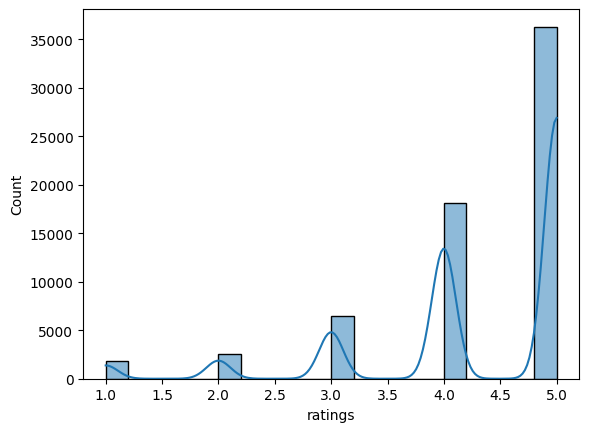

In [11]:
sns.histplot(df['ratings'],bins = 20,kde = True)

In [12]:
t1 = df['ratings'].value_counts()

In [13]:
df['ratings'].value_counts()

ratings
5.0    36315
4.0    18127
3.0     6481
2.0     2515
1.0     1852
Name: count, dtype: int64

<Axes: ylabel='count'>

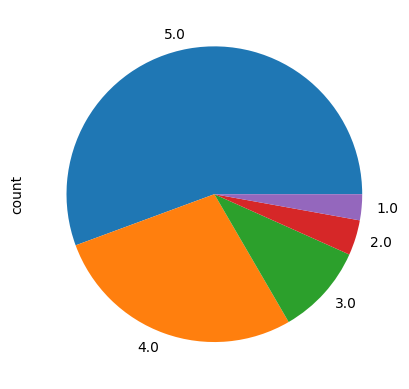

In [14]:
t1.plot(kind = 'pie')

<Axes: xlabel='ratings'>

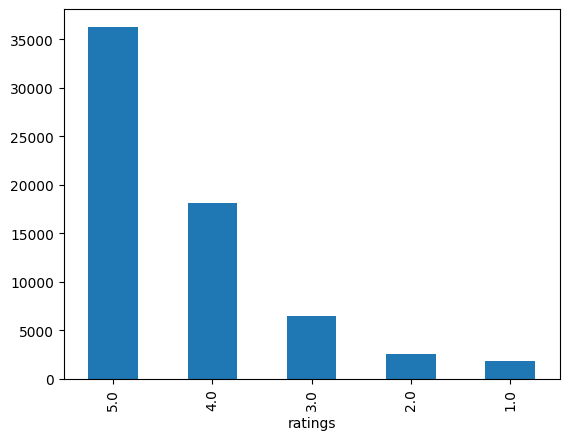

In [15]:
t1.plot(kind = 'bar')

<Axes: xlabel='ratings'>

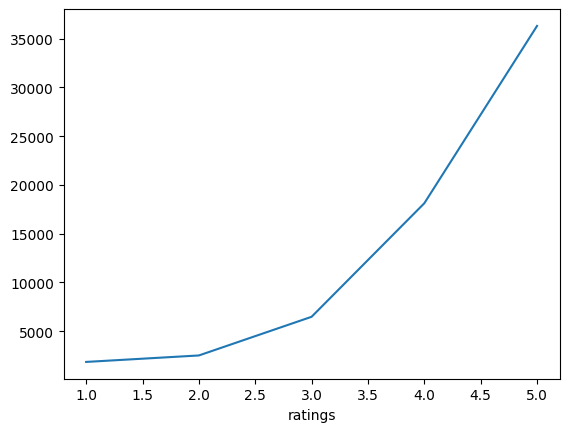

In [16]:
t1.plot(kind = 'line')

In [17]:
top_users = df["user_id"].value_counts().head(20).index
top_users

Index(['ADLVFFE4VBT8', 'A3OXHLG6DIBRW8', 'A1ODOGXEYECQQ8', 'A36K2N527TXXJN',
       'A25C2M3QF9G7OQ', 'A680RUE1FDO8B', 'A1UQBFCERIP7VJ', 'A22CW0ZHY3NJH8',
       'AWPODHOB4GFWL', 'AGVWTYW0ULXHT', 'A3LGT6UZL99IW1', 'A23GFTVIETX7DS',
       'A3AYSYSLHU26U9', 'A3EXWV8FNSSFL6', 'A3A4ZAIBQWKOZS', 'A6FIAB28IS79',
       'A17BUUBOU0598B', 'A2UOHALGF2X77Q', 'A4WEZJOIZIV4U', 'AVPNQUVZWMDSX'],
      dtype='object', name='user_id')

In [18]:
top_products = df["Product_id"].value_counts().head(20).index
top_products

Index(['B0088CJT4U', 'B003ES5ZUU', 'B000N99BBC', 'B007WTAJTO', 'B00829TIEK',
       'B00829THK0', 'B008DWCRQW', 'B002R5AM7C', 'B004CLYEDC', 'B002SZEOLG',
       'B00834SJNA', 'B004T9RR6I', 'B002V88HFE', 'B0034CL2ZI', 'B00834SJSK',
       'B002WE6D44', 'B00829TIA4', 'B004CLYEFK', 'B009SYZ8OC', 'B0079UAT0A'],
      dtype='object', name='Product_id')

In [19]:
filtered_df = df[df["user_id"].isin(top_users) & df['Product_id'].isin(top_products)]
filtered_df

,user_id,Product_id,ratings
1198846,AWPODHOB4GFWL,B000N99BBC,5.0
1199010,A3LGT6UZL99IW1,B000N99BBC,5.0
2796344,ADLVFFE4VBT8,B002R5AM7C,2.0
2796365,A3AYSYSLHU26U9,B002R5AM7C,4.0
2796416,A3OXHLG6DIBRW8,B002R5AM7C,5.0
...,...,...,...
6190309,AVPNQUVZWMDSX,B008DWCRQW,5.0
6190385,A680RUE1FDO8B,B008DWCRQW,4.0
6715851,A3AYSYSLHU26U9,B009SYZ8OC,5.0
6716896,A3OXHLG6DIBRW8,B009SYZ8OC,5.0


In [20]:
df_pivot = filtered_df.pivot_table(
    index="user_id",
    columns="Product_id",
    values="ratings"
)

In [21]:
df_pivot

Product_id,B000N99BBC,B002R5AM7C,B002SZEOLG,B002V88HFE,B002WE6D44,B0034CL2ZI,B003ES5ZUU,B004CLYEDC,B004CLYEFK,B004T9RR6I,B0079UAT0A,B007WTAJTO,B00829THK0,B00829TIA4,B00829TIEK,B00834SJNA,B00834SJSK,B0088CJT4U,B008DWCRQW,B009SYZ8OC
user_id,,,,,,,,,,,,,,,,,,,,
A17BUUBOU0598B,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A1ODOGXEYECQQ8,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A1UQBFCERIP7VJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,NaN,5.0,NaN,4.0,NaN,5.0,NaN,5.0,NaN,NaN,NaN
A22CW0ZHY3NJH8,NaN,NaN,4.0,NaN,NaN,4.0,5.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
A23GFTVIETX7DS,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,NaN,5.0,NaN,5.0,NaN,NaN,NaN,NaN,4.0
A25C2M3QF9G7OQ,NaN,NaN,NaN,NaN,5.0,NaN,NaN,4.0,5.0,5.0,5.0,NaN,5.0,NaN,NaN,5.0,NaN,3.0,2.0,NaN
A2UOHALGF2X77Q,NaN,4.0,NaN,5.0,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A36K2N527TXXJN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0,5.0,NaN,5.0,NaN,NaN,NaN,5.0,NaN,NaN,4.0,NaN,NaN
A3A4ZAIBQWKOZS,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,5.0,5.0,NaN,5.0,5.0,NaN,5.0,NaN,NaN


In [22]:
df_pivot.fillna(value = 0,inplace = True)

In [23]:
df_pivot

Product_id,B000N99BBC,B002R5AM7C,B002SZEOLG,B002V88HFE,B002WE6D44,B0034CL2ZI,B003ES5ZUU,B004CLYEDC,B004CLYEFK,B004T9RR6I,B0079UAT0A,B007WTAJTO,B00829THK0,B00829TIA4,B00829TIEK,B00834SJNA,B00834SJSK,B0088CJT4U,B008DWCRQW,B009SYZ8OC
user_id,,,,,,,,,,,,,,,,,,,,
A17BUUBOU0598B,0.0,3.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1ODOGXEYECQQ8,0.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1UQBFCERIP7VJ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,5.0,0.0,4.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0
A22CW0ZHY3NJH8,0.0,0.0,4.0,0.0,0.0,4.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
A23GFTVIETX7DS,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0,4.0
A25C2M3QF9G7OQ,0.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,5.0,5.0,5.0,0.0,5.0,0.0,0.0,5.0,0.0,3.0,2.0,0.0
A2UOHALGF2X77Q,0.0,4.0,0.0,5.0,5.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A36K2N527TXXJN,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,5.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0
A3A4ZAIBQWKOZS,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,5.0,5.0,0.0,5.0,0.0,0.0


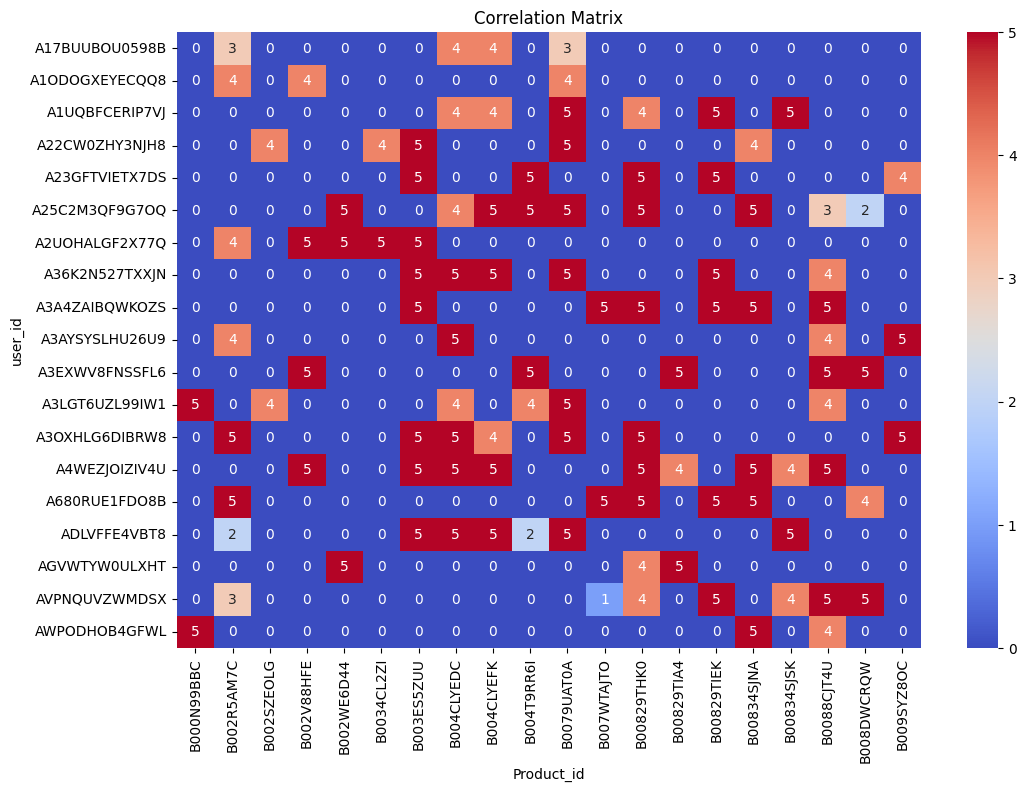

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df_pivot,cmap='coolwarm',annot = True)
plt.title("Correlation Matrix")
plt.show()

In [25]:
d1 = df.pivot_table(index = 'user_id',columns = 'Product_id',values = 'ratings')
d1

Product_id,1400501466,1400532655,1400599997,9983891212,B00000DM9W,B00000J1V5,B00000JDF5,B00000JDF6,B00000K135,B00000K4KH,...,B00KNM763E,B00KONCDVM,B00KVNY2KA,B00KXAFYZS,B00KYMCJF8,B00L21HC7A,B00L2442H0,B00L26YDA4,B00L3YHF6O,B00LGQ6HL8
user_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A100WO06OQR8BQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A105S56ODHGJEK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A105TOJ6LTVMBG,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10AFVU66A79Y1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AZBXKUH4AIW3X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AZCE11PSTCH1L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AZMY6E8B52L2T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.0,5.0,NaN,5.0,5.0,5.0,NaN,NaN


In [27]:
d1.fillna(value = 0,inplace = True)
d1

Product_id,1400501466,1400532655,1400599997,9983891212,B00000DM9W,B00000J1V5,B00000JDF5,B00000JDF6,B00000K135,B00000K4KH,...,B00KNM763E,B00KONCDVM,B00KVNY2KA,B00KXAFYZS,B00KYMCJF8,B00L21HC7A,B00L2442H0,B00L26YDA4,B00L3YHF6O,B00LGQ6HL8
user_id,,,,,,,,,,,,,,,,,,,,,
A100UD67AHFODS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105TOJ6LTVMBG,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10AFVU66A79Y1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AZBXKUH4AIW3X,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZCE11PSTCH1L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AZMY6E8B52L2T,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,5.0,0.0,5.0,5.0,5.0,0.0,0.0


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
d1_scaled = scaler.fit_transform(d1)
d1_scaled

array([[-0.05503985, -0.05841799, -0.05320956, ..., -0.09097831,
        -0.09578263, -0.05707301],
       [-0.05503985, -0.05841799, -0.05320956, ..., -0.09097831,
        -0.09578263, -0.05707301],
       [-0.05503985, -0.05841799, -0.05320956, ..., -0.09097831,
        -0.09578263, -0.05707301],
       ...,
       [-0.05503985, -0.05841799, -0.05320956, ..., 12.19907438,
        -0.09578263, -0.05707301],
       [-0.05503985, -0.05841799, -0.05320956, ..., -0.09097831,
        -0.09578263, -0.05707301],
       [-0.05503985, -0.05841799, -0.05320956, ..., -0.09097831,
        -0.09578263, -0.05707301]], shape=(1540, 5689))

In [30]:
import warnings
warnings.filterwarnings("ignore")

# KMeans Clustering

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(d1_scaled)

print("Silhouette Score:",
      silhouette_score(d1_scaled, clusters))

Silhouette Score: 0.16214322777797885


In [32]:
for k in range(2,11):
    kmeans = KMeans(n_clusters = k,random_state = 42)
    clusters = kmeans.fit_predict(d1_scaled)
    score = silhouette_score(d1_scaled, clusters)
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

Clusters: 2, Silhouette Score: 0.1621
Clusters: 3, Silhouette Score: 0.0750
Clusters: 4, Silhouette Score: 0.0754
Clusters: 5, Silhouette Score: 0.0829
Clusters: 6, Silhouette Score: 0.0829
Clusters: 7, Silhouette Score: 0.0829
Clusters: 8, Silhouette Score: -0.1383
Clusters: 9, Silhouette Score: -0.1380
Clusters: 10, Silhouette Score: -0.1375


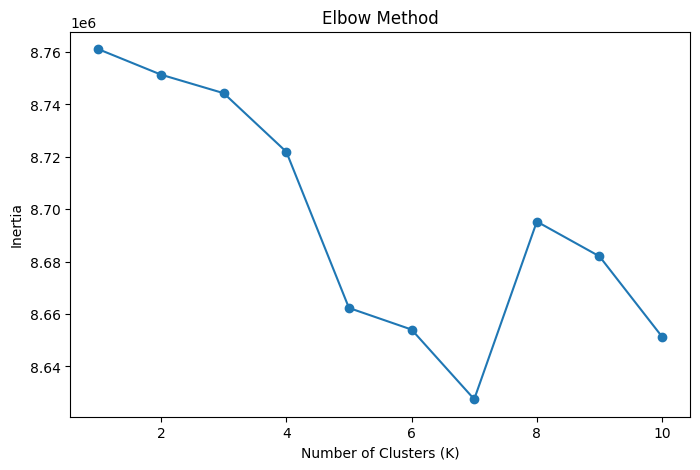

In [35]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(d1_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Hierarchical clustering / Agglomerative Clustering

In [36]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, linkage='single')
hc_labels = hc.fit_predict(d1_scaled)

print("Silhouette Score:",
      silhouette_score(d1_scaled, hc_labels))

Silhouette Score: 0.5093531961764346


In [37]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, linkage='complete')
hc_labels = hc.fit_predict(d1_scaled)

print("Silhouette Score:",
      silhouette_score(d1_scaled, hc_labels))

Silhouette Score: 0.5093531961764346


In [38]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
hc_labels = hc.fit_predict(d1_scaled)

print("Silhouette Score:",
      silhouette_score(d1_scaled, hc_labels))

Silhouette Score: 0.4106834704325394


In [39]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, linkage='average')
hc_labels = hc.fit_predict(d1_scaled)

print("Silhouette Score:",
      silhouette_score(d1_scaled, hc_labels))

Silhouette Score: 0.5093531961764346


# DBSCAN

In [40]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps = 0.3,min_samples = 3)
db_labels = db.fit_predict(d1_scaled)
db_Dataframe = pd.DataFrame(db_labels)
db_Dataframe.columns = ['DBSCAN']
db_Dataframe['DBSCAN'].value_counts()

DBSCAN
-1    1540
Name: count, dtype: int64

In [42]:
from sklearn.metrics import silhouette_score
import numpy as np

mask = db_labels != -1
filtered_labels = db_labels[mask]
filtered_data = d1[mask]

if len(set(filtered_labels)) > 1:
    print("Silhouette Score:",
          silhouette_score(d1_scaled, filtered_labels))
else:
    print("Silhouette score cannot be calculated (only one cluster).")

Silhouette score cannot be calculated (only one cluster).


In [43]:
from sklearn.metrics import pairwise_distances
result  = 1 - pairwise_distances(d1,metric='cosine')
result

array([[1.        , 0.02102415, 0.        , ..., 0.07463811, 0.02970829,
        0.04085987],
       [0.02102415, 1.        , 0.01830968, ..., 0.02909929, 0.        ,
        0.00796506],
       [0.        , 0.01830968, 1.        , ..., 0.00520011, 0.03234074,
        0.        ],
       ...,
       [0.07463811, 0.02909929, 0.00520011, ..., 1.        , 0.02055946,
        0.0565537 ],
       [0.02970829, 0.        , 0.03234074, ..., 0.02055946, 1.        ,
        0.        ],
       [0.04085987, 0.00796506, 0.        , ..., 0.0565537 , 0.        ,
        1.        ]], shape=(1540, 1540))

In [45]:
np.fill_diagonal(result,0)
result

array([[0.        , 0.02102415, 0.        , ..., 0.07463811, 0.02970829,
        0.04085987],
       [0.02102415, 0.        , 0.01830968, ..., 0.02909929, 0.        ,
        0.00796506],
       [0.        , 0.01830968, 0.        , ..., 0.00520011, 0.03234074,
        0.        ],
       ...,
       [0.07463811, 0.02909929, 0.00520011, ..., 0.        , 0.02055946,
        0.0565537 ],
       [0.02970829, 0.        , 0.03234074, ..., 0.02055946, 0.        ,
        0.        ],
       [0.04085987, 0.00796506, 0.        , ..., 0.0565537 , 0.        ,
        0.        ]], shape=(1540, 1540))

In [46]:
result= pd.DataFrame(result)
result

,0,1,2,3,4,5,6,7,8,9,...,1530,1531,1532,1533,1534,1535,1536,1537,1538,1539
0,0.000000,0.021024,0.000000,0.030624,0.019659,0.000000,0.055710,0.067987,0.019697,0.043221,...,0.061563,0.000000,0.000000,0.056362,0.061269,0.000000,0.000000,0.074638,0.029708,0.040860
1,0.021024,0.000000,0.018310,0.029849,0.014371,0.014746,0.027150,0.035342,0.026109,0.004213,...,0.033336,0.006211,0.022182,0.000000,0.032439,0.035008,0.000000,0.029099,0.000000,0.007965
2,0.000000,0.018310,0.000000,0.000000,0.026751,0.076173,0.000000,0.000000,0.038595,0.000000,...,0.000000,0.000000,0.041861,0.000000,0.013175,0.000000,0.000000,0.005200,0.032341,0.000000
3,0.030624,0.029849,0.000000,0.000000,0.000000,0.000000,0.039547,0.006435,0.000000,0.000000,...,0.087403,0.000000,0.022283,0.000000,0.026848,0.040795,0.000000,0.077144,0.000000,0.000000
4,0.019659,0.014371,0.026751,0.000000,0.000000,0.026931,0.000000,0.000000,0.000000,0.024620,...,0.000000,0.000000,0.025033,0.064210,0.067215,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,0.000000,0.035008,0.000000,0.040795,0.000000,0.000000,0.000000,0.037736,0.032798,0.134943,...,0.000000,0.000000,0.000000,0.000000,0.012595,0.000000,0.000000,0.024857,0.000000,0.000000
1536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004601,0.000000,0.000000
1537,0.074638,0.029099,0.005200,0.077144,0.000000,0.000000,0.037783,0.015683,0.013631,0.052344,...,0.071007,0.000000,0.000000,0.000000,0.026173,0.024857,0.004601,0.000000,0.020559,0.056554
1538,0.029708,0.000000,0.032341,0.000000,0.000000,0.106790,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020559,0.000000,0.000000


In [47]:
result.index = df["user_id"].unique()
result.columns = df["user_id"].unique()
result

,A3LDPF5FMB782Z,A1A5KUIIIHFF4U,A2XIOXRRYX0KZY,AW3LX47IHPFRL,A1E3OB6QMBKRYZ,A19N3S7CBSU6O7,A2ZR3YTMEEIIZ4,A3CLWR1UUZT6TG,A5JLAU2ARJ0BO,A1P4XD7IORSEFN,...,A2VALCFTOWFYXZ,A3223W5IROMYTY,A319Y83RT0MRVR,A3AZI828WJN1CD,AT53ZTTO707MB,A1X3ESYZ79H59E,A328S9RN3U5M68,A215WH6RUDUCMP,A38C12950IM24P,A2J4XMWKR8PPD0
A3LDPF5FMB782Z,0.000000,0.021024,0.000000,0.030624,0.019659,0.000000,0.055710,0.067987,0.019697,0.043221,...,0.061563,0.000000,0.000000,0.056362,0.061269,0.000000,0.000000,0.074638,0.029708,0.040860
A1A5KUIIIHFF4U,0.021024,0.000000,0.018310,0.029849,0.014371,0.014746,0.027150,0.035342,0.026109,0.004213,...,0.033336,0.006211,0.022182,0.000000,0.032439,0.035008,0.000000,0.029099,0.000000,0.007965
A2XIOXRRYX0KZY,0.000000,0.018310,0.000000,0.000000,0.026751,0.076173,0.000000,0.000000,0.038595,0.000000,...,0.000000,0.000000,0.041861,0.000000,0.013175,0.000000,0.000000,0.005200,0.032341,0.000000
AW3LX47IHPFRL,0.030624,0.029849,0.000000,0.000000,0.000000,0.000000,0.039547,0.006435,0.000000,0.000000,...,0.087403,0.000000,0.022283,0.000000,0.026848,0.040795,0.000000,0.077144,0.000000,0.000000
A1E3OB6QMBKRYZ,0.019659,0.014371,0.026751,0.000000,0.000000,0.026931,0.000000,0.000000,0.000000,0.024620,...,0.000000,0.000000,0.025033,0.064210,0.067215,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A1X3ESYZ79H59E,0.000000,0.035008,0.000000,0.040795,0.000000,0.000000,0.000000,0.037736,0.032798,0.134943,...,0.000000,0.000000,0.000000,0.000000,0.012595,0.000000,0.000000,0.024857,0.000000,0.000000
A328S9RN3U5M68,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004601,0.000000,0.000000
A215WH6RUDUCMP,0.074638,0.029099,0.005200,0.077144,0.000000,0.000000,0.037783,0.015683,0.013631,0.052344,...,0.071007,0.000000,0.000000,0.000000,0.026173,0.024857,0.004601,0.000000,0.020559,0.056554
A38C12950IM24P,0.029708,0.000000,0.032341,0.000000,0.000000,0.106790,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020559,0.000000,0.000000


In [48]:
result.max()

A3LDPF5FMB782Z    0.125419
A1A5KUIIIHFF4U    0.135993
A2XIOXRRYX0KZY    0.176441
AW3LX47IHPFRL     0.129067
A1E3OB6QMBKRYZ    0.129001
                    ...   
A1X3ESYZ79H59E    0.157138
A328S9RN3U5M68    0.213637
A215WH6RUDUCMP    0.279946
A38C12950IM24P    0.145415
A2J4XMWKR8PPD0    0.157168
Length: 1540, dtype: float64

In [49]:
result.idxmax()

A3LDPF5FMB782Z    A3Q6ZPW60CVF2L
A1A5KUIIIHFF4U    A3NHUQ33CFH3VM
A2XIOXRRYX0KZY     AQB4DH57MSZSC
AW3LX47IHPFRL     A1IU7S4HCK1XK0
A1E3OB6QMBKRYZ     AFFVUZEGP1FDQ
                       ...      
A1X3ESYZ79H59E    A1BZIM4WGZ6DZP
A328S9RN3U5M68    A37D1ZP8GBHE38
A215WH6RUDUCMP     AL5CUWBFBMWYQ
A38C12950IM24P    A209G57KXCBF4C
A2J4XMWKR8PPD0    A259MPG6SOL02P
Length: 1540, dtype: object

In [50]:
result.idxmax()[0:10]

A3LDPF5FMB782Z    A3Q6ZPW60CVF2L
A1A5KUIIIHFF4U    A3NHUQ33CFH3VM
A2XIOXRRYX0KZY     AQB4DH57MSZSC
AW3LX47IHPFRL     A1IU7S4HCK1XK0
A1E3OB6QMBKRYZ     AFFVUZEGP1FDQ
A19N3S7CBSU6O7    A1ZCSSCAGBCD49
A2ZR3YTMEEIIZ4    A178M2AHNWQZB0
A3CLWR1UUZT6TG    A34DQINHT6NYJU
A5JLAU2ARJ0BO      AZOK5STV85FBJ
A1P4XD7IORSEFN    A2V5M5EJPOD2IU
dtype: object

In [51]:
df[(df["user_id"] == 'A3LDPF5FMB782Z') | (df['user_id'] == 'A3Q6ZPW60CVF2L')]

,user_id,Product_id,ratings
1310,A3LDPF5FMB782Z,1400501466,5.0
142510,A3Q6ZPW60CVF2L,B000065BPB,5.0
495941,A3Q6ZPW60CVF2L,B0002MQGK4,2.0
504686,A3LDPF5FMB782Z,B0002SQ0A4,4.0
675474,A3LDPF5FMB782Z,B0009O6IXA,1.0
1017085,A3LDPF5FMB782Z,B000HZDF8W,3.0
1047368,A3LDPF5FMB782Z,B000IF4788,5.0
1210521,A3LDPF5FMB782Z,B000NK8EWI,4.0
1295976,A3LDPF5FMB782Z,B000Q3043Y,5.0
1312372,A3LDPF5FMB782Z,B000QUUFRW,5.0


In [52]:
len(df[(df["user_id"] == 'A3LDPF5FMB782Z') | (df['user_id'] == 'A3Q6ZPW60CVF2L')])

52

In [53]:
df["high_rating"] = df["ratings"].apply(lambda x: 1 if x >= 4 else 0)
df["high_rating"]

1310       1
1322       0
1335       0
1451       1
1456       0
          ..
7824423    1
7824424    1
7824425    1
7824426    1
7824427    1
Name: high_rating, Length: 65290, dtype: int64

In [54]:
user_avg = df.groupby("user_id")["ratings"].mean()
prod_avg = df.groupby("Product_id")["ratings"].mean()
user_avg

user_id
A100UD67AHFODS    4.584906
A100WO06OQR8BQ    3.636364
A105S56ODHGJEK    3.931034
A105TOJ6LTVMBG    4.031250
A10AFVU66A79Y1    4.276596
                    ...   
AZBXKUH4AIW3X     4.181818
AZCE11PSTCH1L     4.434783
AZMY6E8B52L2T     4.723810
AZNUHQSHZHSUE     4.433333
AZOK5STV85FBJ     4.785714
Name: ratings, Length: 1540, dtype: float64

In [55]:
df["user_avg_rating"] = df["user_id"].map(user_avg)
df["prod_avg_rating"] = df["Product_id"].map(prod_avg)


In [57]:
df["user_id"] = df["user_id"].astype("category").cat.codes
df["Product_id"] = df["Product_id"].astype("category").cat.codes

In [58]:
df

,user_id,Product_id,ratings,high_rating,user_avg_rating,prod_avg_rating
1310,1050,0,5.0,1,4.258065,3.333333
1322,125,0,1.0,0,3.333333,3.333333
1335,785,0,3.0,0,4.185714,3.333333
1451,1495,0,5.0,1,3.470588,3.333333
1456,164,0,1.0,0,3.607143,3.333333
...,...,...,...,...,...,...
7824423,870,5688,5.0,1,4.581967,5.000000
7824424,187,5688,5.0,1,4.867925,5.000000
7824425,462,5688,5.0,1,4.576355,5.000000
7824426,163,5688,5.0,1,4.892857,5.000000


# Splitting the data

In [59]:
from sklearn.model_selection import train_test_split
X = df[["user_id", "Product_id", "user_avg_rating", "prod_avg_rating"]]
y = df["high_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree Classifier

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train,y_train)

y_pred_train = DT.predict(X_train)
y_pred_test = DT.predict(X_test)

print("Decision Test Accuracy:", accuracy_score(y_test, y_pred_test))

Decision Test Accuracy: 0.7821258998315209


# Random Forest Classifier

In [66]:
from sklearn.ensemble import RandomForestClassifier 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_test_rf))

Random Forest Test Accuracy: 0.840174605605759
